# V50: Static vs Dynamic with Fee Control (LQ45)

Notebook ini menjwb pertanyaan: **"Bagaimana mengalahkan Markowitz Statis tapi dengan pendekatan Fee?"**

Kita akan membandingkan dua strategi yang sama-sama menggunakan **Fee Control** (Rebalancing Period & Turnover Buffer), namun berbeda dalam penggunaan AI:

1.  **Static Markowitz + Fee Control**: Selalu Invested (Risk ON), Rebalancing Bulanan (20 hari), Buffer 5%.
2.  **Dynamic AI + Fee Control**: Invested berdasarkan AI (Risk ON/OFF), Rebalancing Bulanan (20 hari) atau saat Regime Change, Buffer 5%.

Hypothesis: Dynamic AI akan unggul karena mampu menghindari drawdown besar (Regime Switching), sementara Static akan terekspos terus menerus meskipun sudah menghemat fee.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (SMA Crossover Target) ---
# Sama seperti V47/V48
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic: Universal Fee Control Simulation ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_universal_simulation(test_dates, returns, ai_probs, threshold, 
                             strategy_type='dynamic', # 'dynamic' or 'static'
                             fee=0.0025, 
                             g_lookback=60, 
                             rebal_period=20, 
                             turnover_buffer=0.05):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False
    buffer = 0.05
    days_since_rebal = 999 # Force rebal on first day
    
    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        prev_risk_status = risk_status
        
        # --- 1. Determine Risk Status ---
        if strategy_type == 'static':
            # Static always Risk ON
            risk_status = True
        else:
            # Dynamic AI
            if not risk_status and prob > (threshold + buffer): risk_status = True
            elif risk_status and prob < (threshold - buffer): risk_status = False
        
        regime_changed = (risk_status != prev_risk_status)
        
        # --- 2. Determine Target Weights ---
        target_weights = current_weights.copy()
        
        if not risk_status:
            # Risk OFF -> Cash
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            # Risk ON -> Equity
            # Rebalance if: Regime changed OR Period elapsed
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = get_mis_assets(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                # Fee Control: Check Turnover Buffer
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                # Force rebalance if regime changed (coming from Cash), otherwise check buffer
                # Note: If coming from Cash, turnover is likely 200%, so > buffer naturally.
                if turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
                
                # If budget savings: keep target_weights as current_weights (drifted), reset timer? 
                # If we skipped rebalance, we just keep current drifted weights.
                # But we should NOT reset days_since_rebal if we skipped? 
                # Actually, if we skip, we check again next day? No, periodic check means next period.
                # V48 logic implies: if skipped, we simply hold. Timer increments.
                # To stick to V48 logic: days_since_rebal resets ONLY if we formulated a new plan.
                # Let's verify standard Fee Control practice. 
                # Usually: Check Periodically. If change < buffer, do nothing. Wait for NEXT period.
                # So yes, reset timer even if we didn't trade to avoid checking every single day after.
                days_since_rebal = 0 
            
            days_since_rebal += 1

        # --- 3. Execute & Fees ---
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001: # Avoid floating point noise
            cost = val * turnover_actual * fee
            val -= cost
        
        # --- 4. Portfolio Return ---
        next_date = test_dates[i+1]
        
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    day_ret += w * r
                    new_weights_drifted[asset] = w * (1 + r)
                else:
                    new_weights_drifted[asset] = w
            
            # Drift weights
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        current_weights = new_weights_drifted
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Final Results (2025):
Dynamic AI : 106.82
Static     : 189.85
Benchmark  : 119.78


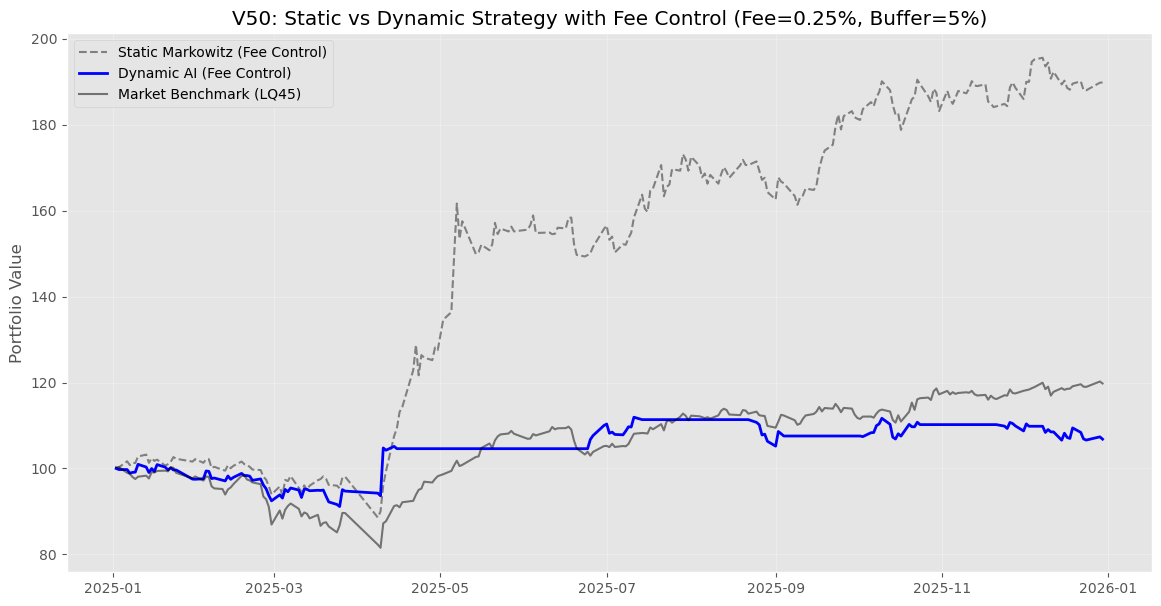

In [4]:
# --- 4. Run Comparisons ---
test_dates = X_test.index

# 1. Static + Fee Control (Baseline)
static_res = run_universal_simulation(test_dates, returns, test_probs, opt_t, 
                                      strategy_type='static', 
                                      fee=0.0025, rebal_period=20, turnover_buffer=0.05)

# 2. Dynamic + Fee Control (Challenger)
dynamic_res = run_universal_simulation(test_dates, returns, test_probs, opt_t, 
                                       strategy_type='dynamic', 
                                       fee=0.0025, rebal_period=20, turnover_buffer=0.05)

# 3. Benchmark (IHSG/LQ45 Equal Weight Buy & Hold)
benchmark = (1 + market_return.loc[test_dates]).cumprod() * 100
benchmark = benchmark.reindex(static_res.index)

# --- 5. Visualization ---
plt.figure(figsize=(14, 7))
plt.plot(static_res.index, static_res['Portfolio_Value'], label='Static Markowitz (Fee Control)', color='gray', linestyle='--')
plt.plot(dynamic_res.index, dynamic_res['Portfolio_Value'], label='Dynamic AI (Fee Control)', color='blue', linewidth=2)
plt.plot(benchmark.index, benchmark, label='Market Benchmark (LQ45)', color='black', alpha=0.5)

plt.title('V50: Static vs Dynamic Strategy with Fee Control (Fee=0.25%, Buffer=5%)')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True, alpha=0.3)

final_static = static_res['Portfolio_Value'].iloc[-1]
final_dynamic = dynamic_res['Portfolio_Value'].iloc[-1]
final_bench = benchmark.iloc[-1]

print(f"Final Results (2025):")
print(f"Dynamic AI : {final_dynamic:.2f}")
print(f"Static     : {final_static:.2f}")
print(f"Benchmark  : {final_bench:.2f}")

plt.savefig('v50_static_vs_dynamic_comparison.png')
plt.show()

In [5]:
# Export Results
results_df = pd.DataFrame({
    'Date': static_res.index,
    'Static_Value': static_res['Portfolio_Value'],
    'Dynamic_Value': dynamic_res['Portfolio_Value'],
    'Benchmark_Value': benchmark
})
results_df.to_excel('v50_strategy_results.xlsx', index=False)
print("✓ Results exported to v50_strategy_results.xlsx")

✓ Results exported to v50_strategy_results.xlsx
